# Mutual information computation

In an neural network layer, the input $X$ is processed as $X \rightarrow h = f(WX) \rightarrow y = g(Wh), with $f$ and $g$ the activation functions.
The mutual information of a hidden activity variable with the inputs or outputs is measured by a MI estimator, to have a finite entropy (as $h$ is a continuous variable with a definite function)
- **Binning**: The variable $h$ is binned in a specific portion of its domain, giving $T_i = B(h_i)$. Now $T_i$ is a discrete variable with finite entropy
-

## MNIST NN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set the seeds for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

In [3]:
# Transformations that are applied to the dataset images when they are loaded: first they are converted to tensors, then flattended from 28x28 images to 784 arrays
transform = transforms.Compose([
    transforms.ToTensor(),                # (1, 28, 28)
    transforms.Lambda(lambda x: x.view(-1))  # (784,)
])

# Load the training dataset
train_dataset = datasets.MNIST(root="MNIST", train=True, download=True, transform=transform)

# Load the test dataset
test_dataset = datasets.MNIST(
    root="MNIST", train=False, download=True, transform=transform
)

# Loaders. These shuffle the images passed in batches of 64 to the model during the training phase
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


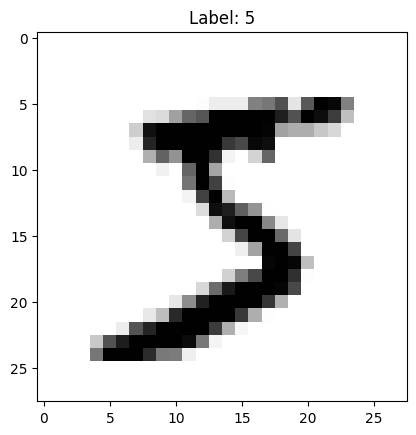

In [4]:
# A small function made for replotting the images

def show_item(index, predicted = None):
    image, label = train_dataset.__getitem__(index)
    image = image.reshape(28,28)

    title = f'Label: {label}' if predicted==None else f'Predicted: {predicted}, true: {label}'
    plt.title(title)
    plt.imshow(image, cmap='gray_r')
    plt.show()

show_item(0)

In [5]:
# Neural network creator

class Net(nn.Module):

    # Pass the hidden layer sizes as a tuple (NOT as a list or a int: if only one pass it as (10,))
    def __init__(self, Nh, Ni=784, No=10, act = nn.Tanh()):
    
        super().__init__()  #Initialize upper modules
        
        self.Nh = Nh
        self.No = No
        self.N_hidden = len(Nh)         # Number of hidden layers
        self.N_features = (Ni, *Nh)  

        # Module list (creates a list of modules that are seen from the library)
        # DO NOT USE A LIST (it is not tracked by torch when weights are updated)
        self.linears = nn.ModuleList([nn.Linear(self.N_features[i], self.N_features[i+1]) for i in range(self.N_hidden)])

        self.act = act

        self.out_layer = nn.Linear(in_features=self.N_features[-1], out_features=No)

        self.train_loss = []
        self.test_loss = []

    # This is a custom forward function that also explicitly returns the hidden variables as a tuple h
    def forward(self, x):
        # Hidden variables
        h = []
        for layer in self.linears:
            a = layer(x)
            x = self.act(a)
            h.append(x)

        return self.out_layer(x), h  


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Net(Nh = (128,64)).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
def get_hidden_variables(model, train_loader):
    # Create the Hidden variables matrices array and initialize it to be empty
    model.eval()
    H = [torch.empty(0, l_hidden) for l_hidden in model.Nh]
    OUTPUT = torch.empty(0, model.No)
    for x,y in train_loader:
        output, batch_h = model(x)
        # For each hidden layer, concatenate the batch h to the whole dataset h
        H = [torch.cat((H[i], batch_h[i]), dim=0) for i in range(model.N_hidden)]
        # Concatenate the outputs too
        OUTPUT = torch.cat((OUTPUT, output), dim=0)
    return H, OUTPUT


def train_model(model, loss_function, optimizer, train_loader, test_loader, epochs=10):

    OUTPUTS = []
    HIDDENS = []

    # Reset the train and test loss records
    model.train_loss = []
    model.test_loss = []

    for epoch in range(epochs):
        # Enter training mode: all computations are recorded for backpropagation, dropout is applied
        model.train()
        train_loss = 0
        train_samples = 0
        train_correct_guess = 0

        # Compute the model for each minibatch
        for x, y in train_loader:

            # Send the batches to the device
            x, y = x.to(device), y.to(device)
            # Reset the gradients
            optimizer.zero_grad()
            pred_y, _ = model(x)
            loss = loss_function(pred_y, y)
            # Record all the gradients for each computation
            loss.backward()
            # Apply Gradient descent
            optimizer.step()

            # Compute the loss for this minibatch
            train_loss += loss.item()

            # Compute the accuracy for this minibatch
            predictions = torch.argmax(pred_y, dim=1)
            train_correct_guess += (predictions == y).sum().item()
            train_samples += y.size(0)

        
        # Exit training mode
        model.eval()
        test_loss = 0.0
        test_samples = 0
        test_correct_guess = 0

        # Stop tracking the gradients
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                # Test the model
                pred_y, _ = model(x)
                loss = loss_function(pred_y,y)

                test_loss += loss

                predictions = torch.argmax(pred_y, dim=1)
                test_correct_guess += (predictions == y).sum().item()
                test_samples += y.size(0)
    
        model.train_loss.append(train_loss)
        model.test_loss.append(test_loss)

        output, hidden = get_hidden_variables(model, test_loader)
        OUTPUTS.append(output)
        HIDDENS.append(hidden)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, Train Acc: {train_correct_guess/train_samples:.4f}, Test Acc: {test_correct_guess/test_samples:.4f}")

    return OUTPUTS, HIDDENS

In [8]:
OUTPUTS, HIDDENS = train_model(model, loss_function, optimizer, train_loader, test_loader, epochs=15)

Epoch [1/15], Train Loss: 127.8499, Test loss: 9.4486, Train Acc: 0.8648, Test Acc: 0.9306
Epoch [2/15], Train Loss: 47.9664, Test loss: 6.5530, Train Acc: 0.9414, Test Acc: 0.9499
Epoch [3/15], Train Loss: 33.9472, Test loss: 5.1594, Train Acc: 0.9579, Test Acc: 0.9607
Epoch [4/15], Train Loss: 25.7226, Test loss: 4.2282, Train Acc: 0.9684, Test Acc: 0.9666
Epoch [5/15], Train Loss: 20.5868, Test loss: 3.8157, Train Acc: 0.9749, Test Acc: 0.9699
Epoch [6/15], Train Loss: 16.4276, Test loss: 3.5052, Train Acc: 0.9796, Test Acc: 0.9725
Epoch [7/15], Train Loss: 13.3779, Test loss: 3.2983, Train Acc: 0.9839, Test Acc: 0.9743
Epoch [8/15], Train Loss: 11.0372, Test loss: 3.0269, Train Acc: 0.9871, Test Acc: 0.9761
Epoch [9/15], Train Loss: 9.0214, Test loss: 3.1943, Train Acc: 0.9892, Test Acc: 0.9755
Epoch [10/15], Train Loss: 7.4435, Test loss: 2.9858, Train Acc: 0.9916, Test Acc: 0.9765
Epoch [11/15], Train Loss: 6.1037, Test loss: 2.9127, Train Acc: 0.9931, Test Acc: 0.9782
Epoch [12/

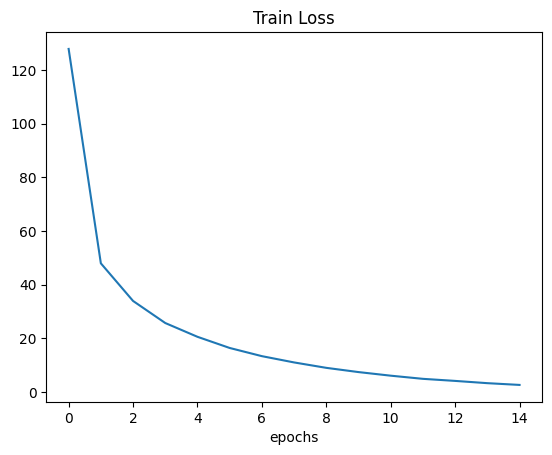

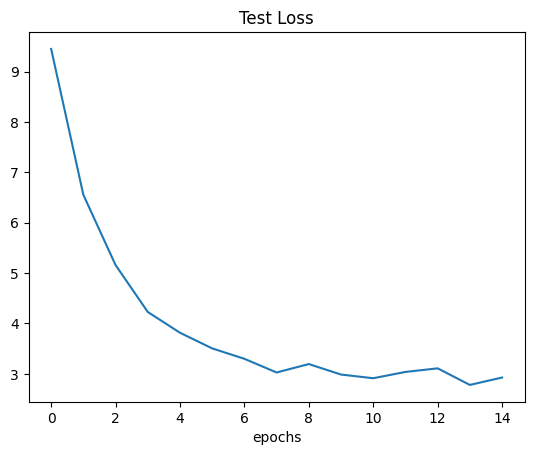

In [9]:
plt.plot(model.train_loss)
plt.title('Train Loss')
plt.xlabel('epochs')
plt.show()
plt.plot(model.test_loss)
plt.title('Test Loss')
plt.xlabel('epochs')
plt.show()


## Mutual information computation

Using binning to constrain the hidden variables to a discrete distribution and so having a finite entropy, the mutula information is $I(X:T) = H(T) - H(T|X)$ with $H(T|X)=0$ as $T_i=binning(h_i)$ and $h_i$ is a deterministic function of $X$. The values used here are multidimensionals, so using $x_i$ and $h_i$ as the components, the 